
# PipelineE K=3 — Fusion input construction + cross-modal BOLD–EEG block maps

This notebook makes **two manuscript-oriented figure sets** for the selected **PipelineE K=3** fusion HMM:

## Part A — Fusion input construction figure
For one representative run, plot:
1. a **BOLD parcel trace** on the TR grid
2. the matching **EEG power-per-TR** trace for the same parcel
3. the **keep mask / usable TRs**
4. optional **EEG sample counts per TR**

This figure is meant for the **Methods**, to show how the TR-aligned fusion input was constructed after handling EEG contamination/exclusion and TR masking.

## Part B — Cross-modal BOLD–EEG block maps
Using the saved state covariance in PCA space and the saved PCA bases:
- backproject the **BOLD–EEG cross-block** for each state
- normalize it to a **cross-modal correlation-like matrix**
- summarize it at the **network × network** level
- plot **state-wise cross-modal block matrices**
- plot **differences versus the dominant/reference state**
- rank the largest **cross-modal network-pair contrasts**

### Important interpretation note
The cross-modal maps are **descriptive summaries of the fitted fusion model**, not independent inferential tests.


In [1]:

from pathlib import Path
import json, math, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

print("Imports ready.")


Imports ready.


In [2]:

# =========================
# CONFIG
# =========================

# Pipeline A per-run alignment outputs
ALIGN_ROOT = Path(
    "/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/align_trmask_lags/"
    "FINAL_v3_gnorm_allTR/intermediate/per_run"
)

# Final selected PipelineE model outputs
RESULT_ROOT = Path(
    "/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/"
    "PipelineE_final_K03_intermediate_nolags_minlen15"
)
FINAL_DIR = RESULT_ROOT / "final"

# Optional: force one run ID such as "sub-01_ses-01"
REPRESENTATIVE_RUN = None

# How to choose the illustrative parcel for the alignment plot
# Options:
#   "max_abs_corr_on_kept" = choose the parcel with largest |corr(BOLD, EEG)| on kept TRs
#   "max_var_eeg"          = choose the parcel with highest EEG variance on kept TRs
#   "fixed"                = use PARCEL_INDEX_FIXED
REPRESENTATIVE_PARCEL_MODE = "max_abs_corr_on_kept"
PARCEL_INDEX_FIXED = 0   # 0-based if mode="fixed"

# Keep-mask file priority for the no-lag minlen15 variant
KEEP_MASK_CANDIDATES = [
    "keep_center_minlen15_lags0.npy",
    "keep_center_lags0.npy",
    "keep_center_minlen15.npy",
]

# Atlas label files
DEFAULT_SCHAEFER_TSV = Path(
    "/mnt/c/EEGFMRI_PIPELINE/templateflow/tpl-MNI152NLin2009cAsym/"
    "tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.tsv"
)
DEFAULT_BRAINSTORM_TXT = Path(
    "/mnt/c/EEGFMRI_PIPELINE/templateflow/tpl-MNI152NLin2009cAsym/"
    "tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-200Parcels7Networks_dseg.txt"
)
PARCEL_LABELS_FILE = None  # override if needed

NETWORK_ORDER = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]

# Figure/output folder
OUT_DIR = RESULT_ROOT / "fusion_methods_and_crossmodal_review"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Quantile caps for heatmap ranges
ABS_VMAX_QUANTILE = 0.98
DIFF_VMAX_QUANTILE = 0.98

print("ALIGN_ROOT :", ALIGN_ROOT)
print("RESULT_ROOT:", RESULT_ROOT)
print("FINAL_DIR  :", FINAL_DIR)
print("OUT_DIR    :", OUT_DIR)


ALIGN_ROOT : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/align_trmask_lags/FINAL_v3_gnorm_allTR/intermediate/per_run
RESULT_ROOT: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15
FINAL_DIR  : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final
OUT_DIR    : /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/fusion_methods_and_crossmodal_review


In [4]:

# =========================
# HELPERS
# =========================

def resolve_existing(*candidates):
    for c in candidates:
        if c is None:
            continue
        p = Path(c)
        if p.exists():
            return p
    return None

def zscore_keep(x, keep):
    x = np.asarray(x, dtype=float)
    keep = np.asarray(keep).astype(bool)
    out = np.full_like(x, np.nan, dtype=float)
    if keep.sum() < 2:
        return out
    mu = np.nanmean(x[keep])
    sd = np.nanstd(x[keep], ddof=0)
    if not np.isfinite(sd) or sd == 0:
        out[keep] = x[keep] - mu
    else:
        out[keep] = (x[keep] - mu) / sd
    return out

def compute_symmetric_limits(arrays, quantile=0.98, floor=1e-8):
    vals = []
    for a in arrays:
        a = np.asarray(a, dtype=float)
        a = a[np.isfinite(a)]
        if a.size:
            vals.append(np.abs(a))
    if not vals:
        return 1.0
    cat = np.concatenate(vals)
    vmax = np.quantile(cat, quantile)
    return float(max(vmax, floor))

def savefig(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    plt.show()

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def infer_result_file(name):
    return resolve_existing(RESULT_ROOT / name, FINAL_DIR / name, Path(name))

def ensure_cov_3d(c):
    c = np.asarray(c)
    if c.ndim == 2:
        c = c[None, ...]
    return c

# --- Schaefer label parsing ---
NETWORK_ALIASES = {
    "Vis": "Vis",
    "SomMot": "SomMot",
    "DorsAttn": "DorsAttn",
    "SalVentAttn": "SalVentAttn",
    "SalVent": "SalVentAttn",
    "VentAttn": "SalVentAttn",
    "Limbic": "Limbic",
    "Cont": "Cont",
    "Control": "Cont",
    "Default": "Default",
    "DefaultMode": "Default",
}

def parse_schaefer_name(name):
    name = str(name)
    hemi = None
    m_hemi = re.search(r'_(LH|RH)_', name)
    if m_hemi:
        hemi = "L" if m_hemi.group(1) == "LH" else "R"
    net = None
    for token in re.split(r"[_\-]", name):
        if token in NETWORK_ALIASES:
            net = NETWORK_ALIASES[token]
            break
    if net is None:
        m = re.search(r'7Networks_(LH|RH)_([^_]+)', name)
        if m:
            net = NETWORK_ALIASES.get(m.group(2), m.group(2))
    return hemi, net

def load_schaefer_table(label_file=None):
    label_path = resolve_existing(label_file, DEFAULT_SCHAEFER_TSV, DEFAULT_BRAINSTORM_TXT)
    if label_path is None:
        raise FileNotFoundError("Could not find Schaefer label table (.tsv or .txt).")
    if label_path.suffix.lower() == ".tsv":
        df = pd.read_csv(label_path, sep="\t")
        id_col = "index" if "index" in df.columns else "id" if "id" in df.columns else None
        if id_col is None:
            ids = np.arange(1, len(df) + 1, dtype=int)
        else:
            ids_series = pd.to_numeric(df[id_col], errors="coerce")
            fallback = pd.Series(np.arange(1, len(df) + 1), index=df.index, dtype="int64")
            ids = ids_series.where(ids_series.notna(), fallback).astype(int).to_numpy()
        name_col = "name" if "name" in df.columns else "label" if "label" in df.columns else df.columns[-1]
        names = df[name_col].astype(str).to_numpy()
    else:
        raw = pd.read_csv(label_path, sep="\t", header=None)
        if raw.shape[1] == 1:
            raw = pd.read_csv(label_path, sep=None, engine="python", header=None)
        raw = raw.iloc[:, :2]
        raw.columns = ["atlas_id", "name"]
        ids = pd.to_numeric(raw["atlas_id"], errors="coerce").fillna(pd.Series(np.arange(1, len(raw) + 1), index=raw.index)).astype(int).to_numpy()
        names = raw["name"].astype(str).to_numpy()

    out = pd.DataFrame({"atlas_id": ids, "label": names})
    out = out[out["atlas_id"] > 0].copy()
    parsed = out["label"].apply(parse_schaefer_name)
    out["hemi"] = [p[0] for p in parsed]
    out["network"] = [p[1] for p in parsed]
    # Keep the first 200 positive labels if a background row sneaks in
    out = out.iloc[:200].copy()
    out["parcel_idx_1based"] = np.arange(1, len(out) + 1)
    out["parcel_idx_0based"] = np.arange(len(out))
    return out

def aggregate_block_matrix(mat, labels_row, labels_col=None, order_row=None, order_col=None):
    mat = np.asarray(mat, dtype=float)
    labels_row = np.asarray(labels_row)
    if labels_col is None:
        labels_col = labels_row
    else:
        labels_col = np.asarray(labels_col)
    if order_row is None:
        order_row = list(pd.unique(labels_row))
    if order_col is None:
        order_col = list(pd.unique(labels_col))
    out = np.full((len(order_row), len(order_col)), np.nan, dtype=float)
    for i, nr in enumerate(order_row):
        idx_r = np.where(labels_row == nr)[0]
        for j, nc in enumerate(order_col):
            idx_c = np.where(labels_col == nc)[0]
            if len(idx_r) == 0 or len(idx_c) == 0:
                continue
            block = mat[np.ix_(idx_r, idx_c)]
            out[i, j] = np.nanmean(block)
    return pd.DataFrame(out, index=order_row, columns=order_col)

def rank_block_contrasts(diff_df, top_n=15):
    rows = []
    for r in diff_df.index:
        for c in diff_df.columns:
            rows.append((r, c, float(diff_df.loc[r, c])))
    out = pd.DataFrame(rows, columns=["bold_network", "eeg_network", "delta_value"])
    out["abs_delta"] = out["delta_value"].abs()
    out = out.sort_values(["abs_delta", "delta_value"], ascending=[False, False]).head(top_n).reset_index(drop=True)
    return out

print("Helpers ready.")


Helpers ready.


In [6]:
# =========================
# RESOLVE REQUIRED FILES (corrected)
# =========================

required = {
    # Core cross-modal backprojection files
    "covs_pca": infer_result_file("covs_pca.npy"),
    "preproc_params": resolve_existing(
        RESULT_ROOT / "preproc_params.npz",
        FINAL_DIR / "preproc_params.npz",
    ),

    # Correct source for FINAL model-level FO vector / reference state
    "best_seed": resolve_existing(
        FINAL_DIR / "best_seed.json",
        RESULT_ROOT / "best_seed.json",
    ),

    # Useful fallbacks / summaries
    "run_metrics": resolve_existing(RESULT_ROOT / "run_metrics.tsv"),
    "subject_metrics": resolve_existing(RESULT_ROOT / "subject_metrics.tsv"),
    "qc_summary": resolve_existing(
        RESULT_ROOT / "qc_summary.json",
        FINAL_DIR / "qc_summary.json",
    ),

    # Optional manuscript-derived summary table if present
    "state_summary_table": resolve_existing(
        RESULT_ROOT / "manuscript_figures" / "tables" / "state_summary_table.tsv",
        RESULT_ROOT / "physiology_review_schaefer" / "tables" / "state_summary_table.tsv",
        Path("/mnt/data/state_summary_table.tsv"),
    ),
}

for k, v in required.items():
    print(f"{k:18s} -> {v}")

if required["covs_pca"] is None or required["preproc_params"] is None:
    raise FileNotFoundError(
        "Need covs_pca.npy and preproc_params.npz for cross-modal backprojection."
    )

if required["best_seed"] is None:
    print("WARNING: best_seed.json not found. Reference-state selection will use fallbacks.")

schaefer_df = load_schaefer_table(PARCEL_LABELS_FILE)

print("\nLabel table head:")
print(schaefer_df.head())

print("\nNetwork counts:")
print(schaefer_df["network"].value_counts(dropna=False).sort_index())

covs_pca           -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/covs_pca.npy
preproc_params     -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/preproc_params.npz
best_seed          -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/best_seed.json
run_metrics        -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/run_metrics.tsv
subject_metrics    -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/subject_metrics.tsv
qc_summary         -> /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/qc_summary.json
state_summary_table -> /m

In [7]:
# =========================
# PART A — REPRESENTATIVE ALIGNED RUN (corrected cleaner selection)
# =========================

# Optional manual override
REPRESENTATIVE_RUN = None   # e.g. "sub-20_ses-01"

# Screening parameters for a cleaner methods figure
TOP_RUNS_TO_SCREEN = 8
MIN_KEPT_TRS_FOR_SCREEN = 150
MAX_ABS_EEG_Z_ALLOWED = 5.0
MAX_ABS_BOLD_Z_ALLOWED = 5.0

run_dirs = sorted([p for p in ALIGN_ROOT.glob("sub-*_ses-*") if p.is_dir()])
if not run_dirs:
    raise FileNotFoundError(f"No per-run folders found under {ALIGN_ROOT}")

def pick_keep_mask(run_dir):
    for name in KEEP_MASK_CANDIDATES:
        p = run_dir / name
        if p.exists():
            return p
    return None

rows = []
for rd in run_dirs:
    keep_path = pick_keep_mask(rd)
    if keep_path is None:
        continue
    keep = np.load(keep_path).astype(bool)
    rows.append({
        "run": rd.name,
        "run_dir": str(rd),
        "n_tr": int(len(keep)),
        "n_keep": int(keep.sum()),
        "keep_frac": float(keep.mean()) if len(keep) else np.nan,
        "keep_mask_file": keep_path.name,
    })

run_manifest = (
    pd.DataFrame(rows)
    .sort_values(["keep_frac", "n_keep", "run"], ascending=[False, False, True])
    .reset_index(drop=True)
)

print("Detected runs with usable no-lag masks:")
display(run_manifest.head(12) if "display" in globals() else run_manifest.head(12))

def screen_run_for_best_parcel(run_dir):
    bold_path = run_dir / "bold_pc1.npy"
    eeg_path = run_dir / "eeg_power_tr.npy"
    keep_path = pick_keep_mask(run_dir)

    if keep_path is None or not bold_path.exists() or not eeg_path.exists():
        return None

    bold = np.load(bold_path)
    eeg = np.load(eeg_path)
    keep = np.load(keep_path).astype(bool)

    if keep.sum() < MIN_KEPT_TRS_FOR_SCREEN:
        return None

    best = None
    for j in range(bold.shape[1]):
        xb = bold[:, j]
        xe = eeg[:, j]
        m = keep & np.isfinite(xb) & np.isfinite(xe)
        if m.sum() < MIN_KEPT_TRS_FOR_SCREEN:
            continue

        bz = zscore_keep(xb, m)
        ez = zscore_keep(xe, m)

        corr = np.corrcoef(xb[m], xe[m])[0, 1]
        max_abs_bz = float(np.nanmax(np.abs(bz[m])))
        max_abs_ez = float(np.nanmax(np.abs(ez[m])))

        # Penalize extreme spikes so the figure emphasizes alignment rather than outliers
        spike_penalty = 0.0
        if max_abs_bz > MAX_ABS_BOLD_Z_ALLOWED:
            spike_penalty += 0.20 * (max_abs_bz - MAX_ABS_BOLD_Z_ALLOWED)
        if max_abs_ez > MAX_ABS_EEG_Z_ALLOWED:
            spike_penalty += 0.20 * (max_abs_ez - MAX_ABS_EEG_Z_ALLOWED)

        # Prefer reasonable |corr| with low spike burden
        score = abs(corr) - spike_penalty

        row = {
            "parcel_idx": j,
            "corr": float(corr),
            "abs_corr": float(abs(corr)),
            "max_abs_bold_z": max_abs_bz,
            "max_abs_eeg_z": max_abs_ez,
            "score": float(score),
        }

        if (best is None) or (row["score"] > best["score"]):
            best = row

    return best

if REPRESENTATIVE_RUN is not None:
    chosen_run = REPRESENTATIVE_RUN
    run_dir = ALIGN_ROOT / chosen_run
else:
    candidates = run_manifest.head(min(TOP_RUNS_TO_SCREEN, len(run_manifest))).copy()
    scored = []

    for _, rr in candidates.iterrows():
        rd = Path(rr["run_dir"])
        best = screen_run_for_best_parcel(rd)
        if best is None:
            continue
        best["run"] = rr["run"]
        best["run_dir"] = str(rd)
        best["keep_frac"] = rr["keep_frac"]
        best["n_keep"] = rr["n_keep"]
        scored.append(best)

    scored_df = (
        pd.DataFrame(scored)
        .sort_values(["score", "keep_frac", "abs_corr"], ascending=[False, False, False])
        .reset_index(drop=True)
    )

    print("\nBest representative run/parcel candidates:")
    display(scored_df.head(10) if "display" in globals() else scored_df.head(10))

    chosen_run = scored_df.iloc[0]["run"]
    chosen_parcel_idx = int(scored_df.iloc[0]["parcel_idx"])
    run_dir = ALIGN_ROOT / chosen_run

print("Chosen representative run:", chosen_run)

# Required per-run files
bold_path = run_dir / "bold_pc1.npy"
eeg_path = run_dir / "eeg_power_tr.npy"
tr_edges_path = run_dir / "tr_edges_sec.npy"
counts_path = run_dir / "eeg_counts_per_tr.npy"
keep_path = pick_keep_mask(run_dir)

for p in [bold_path, eeg_path, tr_edges_path, keep_path]:
    if p is None or not Path(p).exists():
        raise FileNotFoundError(f"Missing required per-run file: {p}")

bold = np.load(bold_path)
eeg = np.load(eeg_path)
tr_edges = np.load(tr_edges_path)
keep = np.load(keep_path).astype(bool)
eeg_counts = np.load(counts_path) if counts_path.exists() else None

assert bold.shape[0] == eeg.shape[0] == len(keep), "TR dimension mismatch in representative run."
assert bold.shape[1] == eeg.shape[1] == len(schaefer_df), "Parcel dimension mismatch."

# If the run was manually forced, still pick the cleanest parcel within that run
if REPRESENTATIVE_RUN is not None:
    best = screen_run_for_best_parcel(run_dir)
    if best is None:
        chosen_parcel_idx = 0
    else:
        chosen_parcel_idx = int(best["parcel_idx"])

parcel_idx = int(chosen_parcel_idx)
parcel_label = schaefer_df.iloc[parcel_idx]["label"]
parcel_network = schaefer_df.iloc[parcel_idx]["network"]
parcel_hemi = schaefer_df.iloc[parcel_idx]["hemi"]

print(
    f"Chosen parcel: idx={parcel_idx} | "
    f"label={parcel_label} | network={parcel_network} | hemi={parcel_hemi}"
)

bold_z = zscore_keep(bold[:, parcel_idx], keep)
eeg_z = zscore_keep(eeg[:, parcel_idx], keep)

rep_summary = pd.DataFrame([{
    "run": chosen_run,
    "parcel_idx_0based": parcel_idx,
    "parcel_idx_1based": parcel_idx + 1,
    "parcel_label": parcel_label,
    "network": parcel_network,
    "hemi": parcel_hemi,
    "n_tr": int(len(keep)),
    "n_keep": int(keep.sum()),
    "keep_frac": float(keep.mean()),
    "mask_file": keep_path.name,
    "corr_bold_vs_eeg_on_kept": (
        float(np.corrcoef(bold[:, parcel_idx][keep], eeg[:, parcel_idx][keep])[0, 1])
        if keep.sum() >= 5 else np.nan
    ),
    "max_abs_bold_z_on_kept": float(np.nanmax(np.abs(bold_z[keep]))),
    "max_abs_eeg_z_on_kept": float(np.nanmax(np.abs(eeg_z[keep]))),
}])

rep_summary.to_csv(TABLE_DIR / "representative_alignment_run_summary.tsv", sep="\t", index=False)
rep_summary

Detected runs with usable no-lag masks:


,run,run_dir,n_tr,n_keep,keep_frac,keep_mask_file
0,sub-20_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,283,0.982639,keep_center_minlen15_lags0.npy
1,sub-01_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,277,0.961806,keep_center_minlen15_lags0.npy
2,sub-02_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,276,0.958333,keep_center_minlen15_lags0.npy
3,sub-14_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,270,0.937500,keep_center_minlen15_lags0.npy
4,sub-17_ses-02,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,265,0.920139,keep_center_minlen15_lags0.npy
5,sub-03_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,255,0.885417,keep_center_minlen15_lags0.npy
6,sub-13_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,255,0.885417,keep_center_minlen15_lags0.npy
7,sub-13_ses-02,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,240,0.833333,keep_center_minlen15_lags0.npy
8,sub-09_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,234,0.812500,keep_center_minlen15_lags0.npy
9,sub-17_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,288,234,0.812500,keep_center_minlen15_lags0.npy



Best representative run/parcel candidates:


,parcel_idx,corr,abs_corr,max_abs_bold_z,max_abs_eeg_z,score,run,run_dir,keep_frac,n_keep
0,124,0.241802,0.241802,2.749050,3.650475,0.241802,sub-13_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,0.885417,255
1,87,-0.188152,0.188152,3.571698,3.790210,0.188152,sub-03_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,0.885417,255
2,164,-0.183732,0.183732,2.770428,4.300386,0.183732,sub-02_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,0.958333,276
3,42,0.172955,0.172955,3.070529,4.558289,0.172955,sub-20_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,0.982639,283
4,61,-0.153046,0.153046,2.683144,4.863716,0.153046,sub-17_ses-02,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,0.920139,265
5,178,-0.144435,0.144435,2.857313,4.377386,0.144435,sub-01_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,0.961806,277
6,171,0.132840,0.132840,3.278276,4.915339,0.132840,sub-13_ses-02,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,0.833333,240
7,180,-0.128590,0.128590,2.869914,3.739850,0.128590,sub-14_ses-01,/mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fu...,0.937500,270


Chosen representative run: sub-13_ses-01
Chosen parcel: idx=124 | label=7Networks_RH_SomMot_10 | network=SomMot | hemi=R


,run,parcel_idx_0based,parcel_idx_1based,parcel_label,network,hemi,n_tr,n_keep,keep_frac,mask_file,corr_bold_vs_eeg_on_kept,max_abs_bold_z_on_kept,max_abs_eeg_z_on_kept
0,sub-13_ses-01,124,125,7Networks_RH_SomMot_10,SomMot,R,288,255,0.885417,keep_center_minlen15_lags0.npy,0.241802,2.74905,3.650475


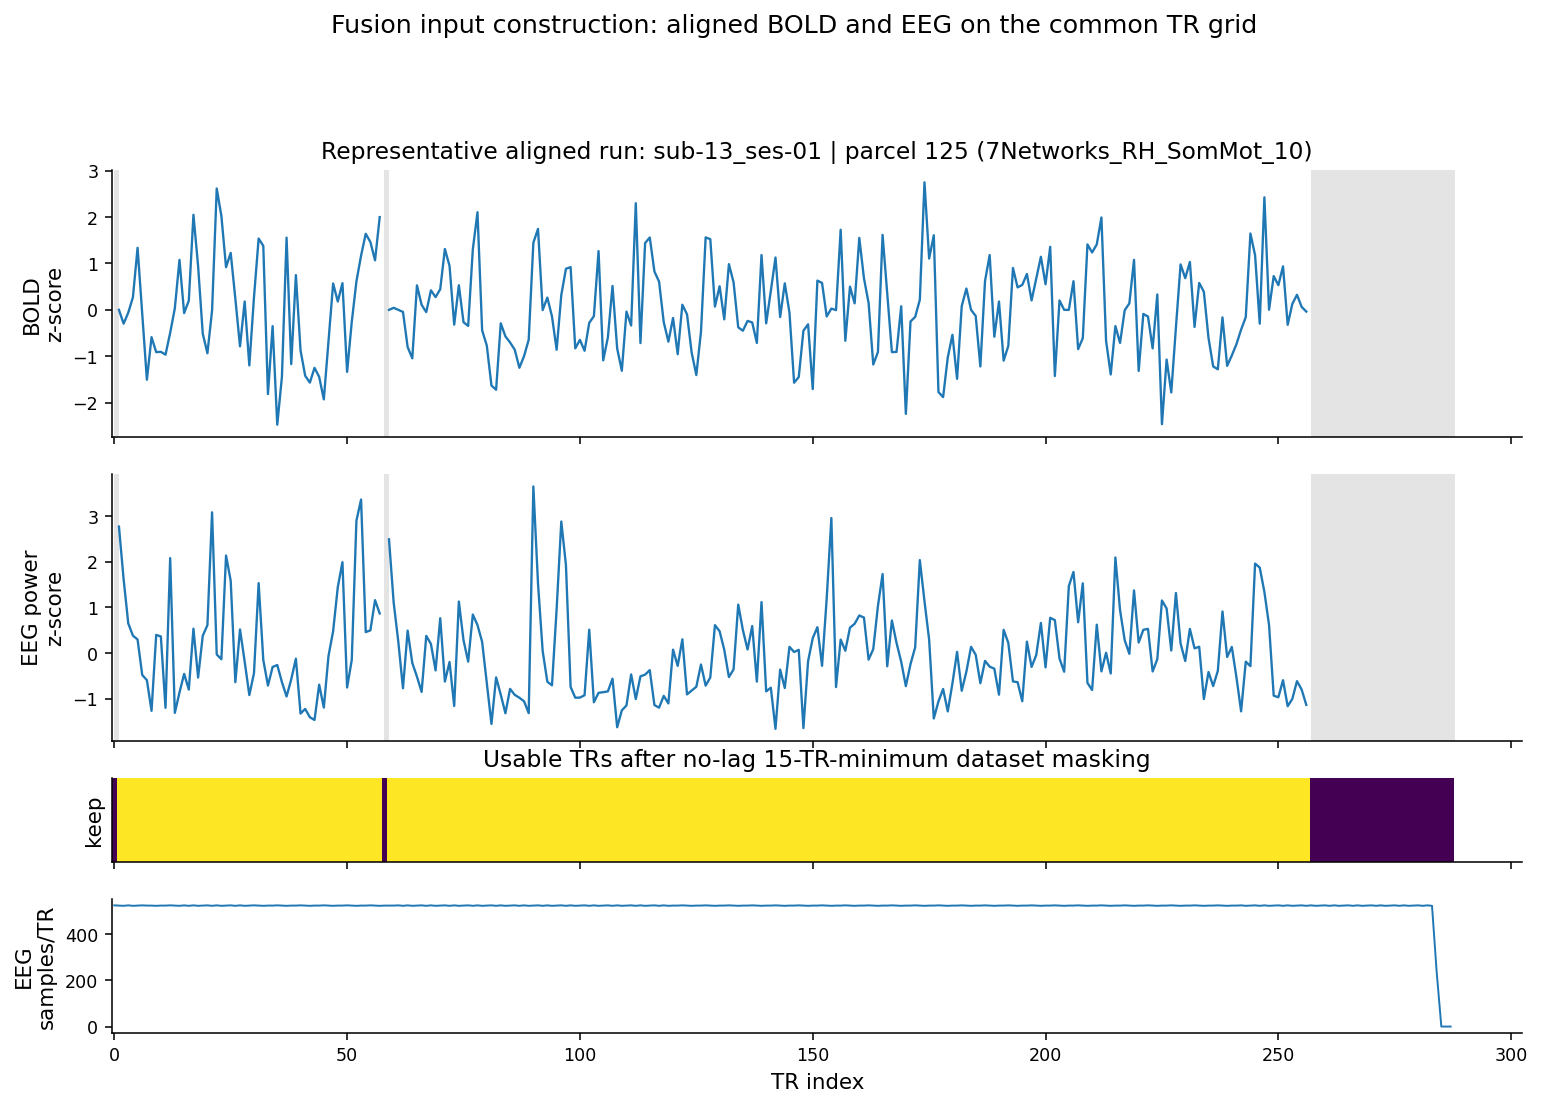

In [8]:

# Plot representative aligned run
x = np.arange(len(keep))
dropped = ~keep

fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True,
                         gridspec_kw={"height_ratios":[1.6, 1.6, 0.5, 0.8]})

# 1) BOLD trace
axes[0].plot(x, bold_z, lw=1.2)
axes[0].set_ylabel("BOLD\nz-score")
axes[0].set_title(
    f"Representative aligned run: {chosen_run} | parcel {parcel_idx+1} ({parcel_label})"
)

# 2) EEG power trace
axes[1].plot(x, eeg_z, lw=1.2)
axes[1].set_ylabel("EEG power\nz-score")

# Shade dropped TRs on top two panels
if dropped.any():
    starts = np.where(np.diff(np.r_[False, dropped, False].astype(int)) == 1)[0]
    stops  = np.where(np.diff(np.r_[False, dropped, False].astype(int)) == -1)[0]
    for a in axes[:2]:
        for s, t in zip(starts, stops):
            a.axvspan(s, t, color="0.85", alpha=0.7, lw=0)

# 3) Keep mask
axes[2].imshow(keep[None, :].astype(int), aspect="auto", interpolation="nearest")
axes[2].set_yticks([])
axes[2].set_ylabel("keep")
axes[2].set_title("Usable TRs after no-lag 15-TR-minimum dataset masking")

# 4) EEG counts per TR
if eeg_counts is not None:
    axes[3].plot(x, eeg_counts, lw=1.0)
    axes[3].set_ylabel("EEG\nsamples/TR")
else:
    axes[3].text(0.5, 0.5, "eeg_counts_per_tr.npy not found", ha="center", va="center", transform=axes[3].transAxes)
    axes[3].set_yticks([])
axes[3].set_xlabel("TR index")

fig.suptitle("Fusion input construction: aligned BOLD and EEG on the common TR grid", y=1.02, fontsize=13)
savefig(fig, "Fig_methods_fusion_input_construction_representative_run.png")



### Interpretation note for the alignment figure
This figure is meant to show **how the fused input was constructed**, not to claim a single-run BOLD–EEG effect for the displayed parcel.  
Both traces are shown on the **same TR grid** after EEG was collapsed into **power-per-TR** and after run-specific TR masking/segment filtering.


In [7]:
# =========================
# PART B — CROSS-MODAL BOLD–EEG BLOCK MAPS (corrected reference-state logic)
# =========================

# Optional manual override
REFERENCE_STATE_OVERRIDE = None   # e.g. "S2"

covs_pca = ensure_cov_3d(np.load(required["covs_pca"]))
pp = np.load(required["preproc_params"])

Vb = pp["Vb"]
Ve = pp["Ve"]
nb = Vb.shape[1]
ne = Ve.shape[1]

print("covs_pca shape:", covs_pca.shape)
print("Vb shape      :", Vb.shape)
print("Ve shape      :", Ve.shape)

if covs_pca.shape[1] < nb + ne or covs_pca.shape[2] < nb + ne:
    raise ValueError("covs_pca dimensions do not match nb+ne from preproc_params.npz")

# -------------------------------------------------
# Correct reference state determination
# Priority:
# 1) explicit manual override
# 2) FINAL_DIR / best_seed.json (correct final model-level FO vector)
# 3) state_summary_table.tsv
# 4) weighted subject/run FO summaries
# 5) fallback to S2
# -------------------------------------------------
final_fo = None
reference_state_idx = None
fo_source = None

if REFERENCE_STATE_OVERRIDE is not None:
    reference_state_idx = int(str(REFERENCE_STATE_OVERRIDE).replace("S", "")) - 1
    fo_source = f"manual override ({REFERENCE_STATE_OVERRIDE})"

elif required["best_seed"] is not None:
    best_info = load_json(required["best_seed"])
    if isinstance(best_info, dict) and "fo" in best_info:
        final_fo = np.asarray(best_info["fo"], dtype=float)
        reference_state_idx = int(np.nanargmax(final_fo))
        fo_source = str(required["best_seed"])

elif required["state_summary_table"] is not None:
    ss = pd.read_csv(required["state_summary_table"], sep="\t")
    if "is_reference" in ss.columns and ss["is_reference"].astype(int).sum() == 1:
        reference_state_idx = int(np.flatnonzero(ss["is_reference"].astype(int).to_numpy())[0])
        fo_source = str(required["state_summary_table"]) + " (is_reference)"
        if "final_FO" in ss.columns:
            final_fo = ss["final_FO"].astype(float).to_numpy()
    elif "is_dominant" in ss.columns and ss["is_dominant"].astype(int).sum() == 1:
        reference_state_idx = int(np.flatnonzero(ss["is_dominant"].astype(int).to_numpy())[0])
        fo_source = str(required["state_summary_table"]) + " (is_dominant)"
        if "final_FO" in ss.columns:
            final_fo = ss["final_FO"].astype(float).to_numpy()
    elif "final_FO" in ss.columns:
        final_fo = ss["final_FO"].astype(float).to_numpy()
        reference_state_idx = int(np.nanargmax(final_fo))
        fo_source = str(required["state_summary_table"]) + " (final_FO)"

elif required["subject_metrics"] is not None:
    sm = pd.read_csv(required["subject_metrics"], sep="\t")
    fo_cols = [c for c in sm.columns if c.startswith("FO_s")]
    if len(fo_cols):
        final_fo = sm[fo_cols].mean(axis=0).to_numpy(dtype=float)
        reference_state_idx = int(np.nanargmax(final_fo))
        fo_source = str(required["subject_metrics"]) + " (mean subject FO)"

elif required["run_metrics"] is not None:
    rm = pd.read_csv(required["run_metrics"], sep="\t")
    fo_cols = [c for c in rm.columns if c.startswith("FO_s")]
    if len(fo_cols):
        final_fo = rm[fo_cols].mean(axis=0).to_numpy(dtype=float)
        reference_state_idx = int(np.nanargmax(final_fo))
        fo_source = str(required["run_metrics"]) + " (mean run FO)"

else:
    reference_state_idx = 1
    fo_source = "fallback default S2"

if reference_state_idx is None:
    reference_state_idx = 1
    fo_source = "fallback default S2"

ref_state = f"S{reference_state_idx + 1}"

print("Reference-state source:", fo_source)
if final_fo is not None:
    print("Final FO vector used:", np.round(final_fo, 6))
print("Reference state:", ref_state)

# -------------------------------------------------
# Backproject state-wise BOLD, EEG, and cross-modal blocks
# -------------------------------------------------
def backproject_modal_blocks(covs_pca, Vb, Ve):
    covs_pca = ensure_cov_3d(covs_pca)
    K = covs_pca.shape[0]
    out_bb, out_ee, out_be = [], [], []

    for k in range(K):
        Cbb_p = covs_pca[k, :Vb.shape[1], :Vb.shape[1]]
        Cee_p = covs_pca[k, Vb.shape[1]:Vb.shape[1]+Ve.shape[1], Vb.shape[1]:Vb.shape[1]+Ve.shape[1]]
        Cbe_p = covs_pca[k, :Vb.shape[1], Vb.shape[1]:Vb.shape[1]+Ve.shape[1]]

        Cbb = (Vb @ Cbb_p @ Vb.T).astype(np.float32)
        Cee = (Ve @ Cee_p @ Ve.T).astype(np.float32)
        Cbe = (Vb @ Cbe_p @ Ve.T).astype(np.float32)

        out_bb.append(Cbb)
        out_ee.append(Cee)
        out_be.append(Cbe)

    return np.stack(out_bb), np.stack(out_ee), np.stack(out_be)

def cov_to_crosscorr(Cbb, Cee, Cbe, eps=1e-8):
    vb = np.sqrt(np.clip(np.diag(Cbb), eps, None))
    ve = np.sqrt(np.clip(np.diag(Cee), eps, None))
    denom = np.outer(vb, ve)
    return Cbe / denom

cov_bb, cov_ee, cov_be = backproject_modal_blocks(covs_pca, Vb, Ve)
crosscorr = np.stack([cov_to_crosscorr(cov_bb[k], cov_ee[k], cov_be[k]) for k in range(cov_be.shape[0])])

print("Backprojected shapes:")
print("  cov_bb   :", cov_bb.shape)
print("  cov_ee   :", cov_ee.shape)
print("  cov_be   :", cov_be.shape)
print("  crosscorr:", crosscorr.shape)

np.save(TABLE_DIR / "state_crossmodal_crosscorr_parcel.npy", crosscorr)

covs_pca shape: (3, 80, 80)
Vb shape      : (200, 40)
Ve shape      : (200, 40)
Reference-state source: /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/final/best_seed.json
Final FO vector used: [0.089823 0.807597 0.10258 ]
Reference state: S2
Backprojected shapes:
  cov_bb   : (3, 200, 200)
  cov_ee   : (3, 200, 200)
  cov_be   : (3, 200, 200)
  crosscorr: (3, 200, 200)


In [8]:

# Backproject state-wise BOLD, EEG, and cross-modal blocks into parcel space

def backproject_modal_blocks(covs_pca, Vb, Ve):
    covs_pca = ensure_cov_3d(covs_pca)
    K = covs_pca.shape[0]
    out_bb, out_ee, out_be = [], [], []
    for k in range(K):
        Cbb_p = covs_pca[k, :Vb.shape[1], :Vb.shape[1]]
        Cee_p = covs_pca[k, Vb.shape[1]:Vb.shape[1]+Ve.shape[1], Vb.shape[1]:Vb.shape[1]+Ve.shape[1]]
        Cbe_p = covs_pca[k, :Vb.shape[1], Vb.shape[1]:Vb.shape[1]+Ve.shape[1]]

        Cbb = (Vb @ Cbb_p @ Vb.T).astype(np.float32)
        Cee = (Ve @ Cee_p @ Ve.T).astype(np.float32)
        Cbe = (Vb @ Cbe_p @ Ve.T).astype(np.float32)

        out_bb.append(Cbb)
        out_ee.append(Cee)
        out_be.append(Cbe)
    return np.stack(out_bb), np.stack(out_ee), np.stack(out_be)

def cov_to_crosscorr(Cbb, Cee, Cbe, eps=1e-8):
    vb = np.sqrt(np.clip(np.diag(Cbb), eps, None))
    ve = np.sqrt(np.clip(np.diag(Cee), eps, None))
    denom = np.outer(vb, ve)
    return Cbe / denom

cov_bb, cov_ee, cov_be = backproject_modal_blocks(covs_pca, Vb, Ve)
crosscorr = np.stack([cov_to_crosscorr(cov_bb[k], cov_ee[k], cov_be[k]) for k in range(cov_be.shape[0])])

print("Backprojected shapes:")
print("  cov_bb   :", cov_bb.shape)
print("  cov_ee   :", cov_ee.shape)
print("  cov_be   :", cov_be.shape)
print("  crosscorr:", crosscorr.shape)

# Save raw parcel-level cross-modal matrices
np.save(TABLE_DIR / "state_crossmodal_crosscorr_parcel.npy", crosscorr)


Backprojected shapes:
  cov_bb   : (3, 200, 200)
  cov_ee   : (3, 200, 200)
  cov_be   : (3, 200, 200)
  crosscorr: (3, 200, 200)


In [9]:

# Build network-level BOLD-network × EEG-network block matrices

labels = schaefer_df["network"].to_numpy()
state_block_mats = {}
for k in range(crosscorr.shape[0]):
    df_block = aggregate_block_matrix(
        crosscorr[k],
        labels_row=labels,
        labels_col=labels,
        order_row=NETWORK_ORDER,
        order_col=NETWORK_ORDER,
    )
    state_block_mats[f"S{k+1}"] = df_block
    df_block.to_csv(TABLE_DIR / f"crossmodal_block_matrix_S{k+1}.tsv", sep="\t")

# Show the state block matrices
for state, dfb in state_block_mats.items():
    print("\n", state)
    print(dfb.round(3))



 S1
               Vis  SomMot  DorsAttn  SalVentAttn  Limbic   Cont  Default
Vis          0.037   0.042     0.030        0.045   0.052  0.043    0.054
SomMot       0.022   0.006     0.021        0.009   0.009  0.005    0.015
DorsAttn     0.011   0.009    -0.008       -0.005   0.006  0.007    0.004
SalVentAttn  0.031   0.036     0.019        0.016   0.026  0.016    0.023
Limbic       0.005   0.009     0.016        0.021   0.008  0.009    0.017
Cont         0.015   0.021     0.027        0.013   0.032  0.008    0.009
Default     -0.017  -0.016    -0.004       -0.018  -0.019 -0.022   -0.016

 S2
               Vis  SomMot  DorsAttn  SalVentAttn  Limbic   Cont  Default
Vis         -0.016  -0.022    -0.027       -0.026  -0.024 -0.019   -0.021
SomMot      -0.002   0.000     0.000        0.000  -0.000 -0.001   -0.005
DorsAttn     0.009   0.001     0.007        0.007   0.003  0.005    0.005
SalVentAttn -0.011  -0.015    -0.010       -0.010  -0.009 -0.010   -0.009
Limbic       0.002   0.008  

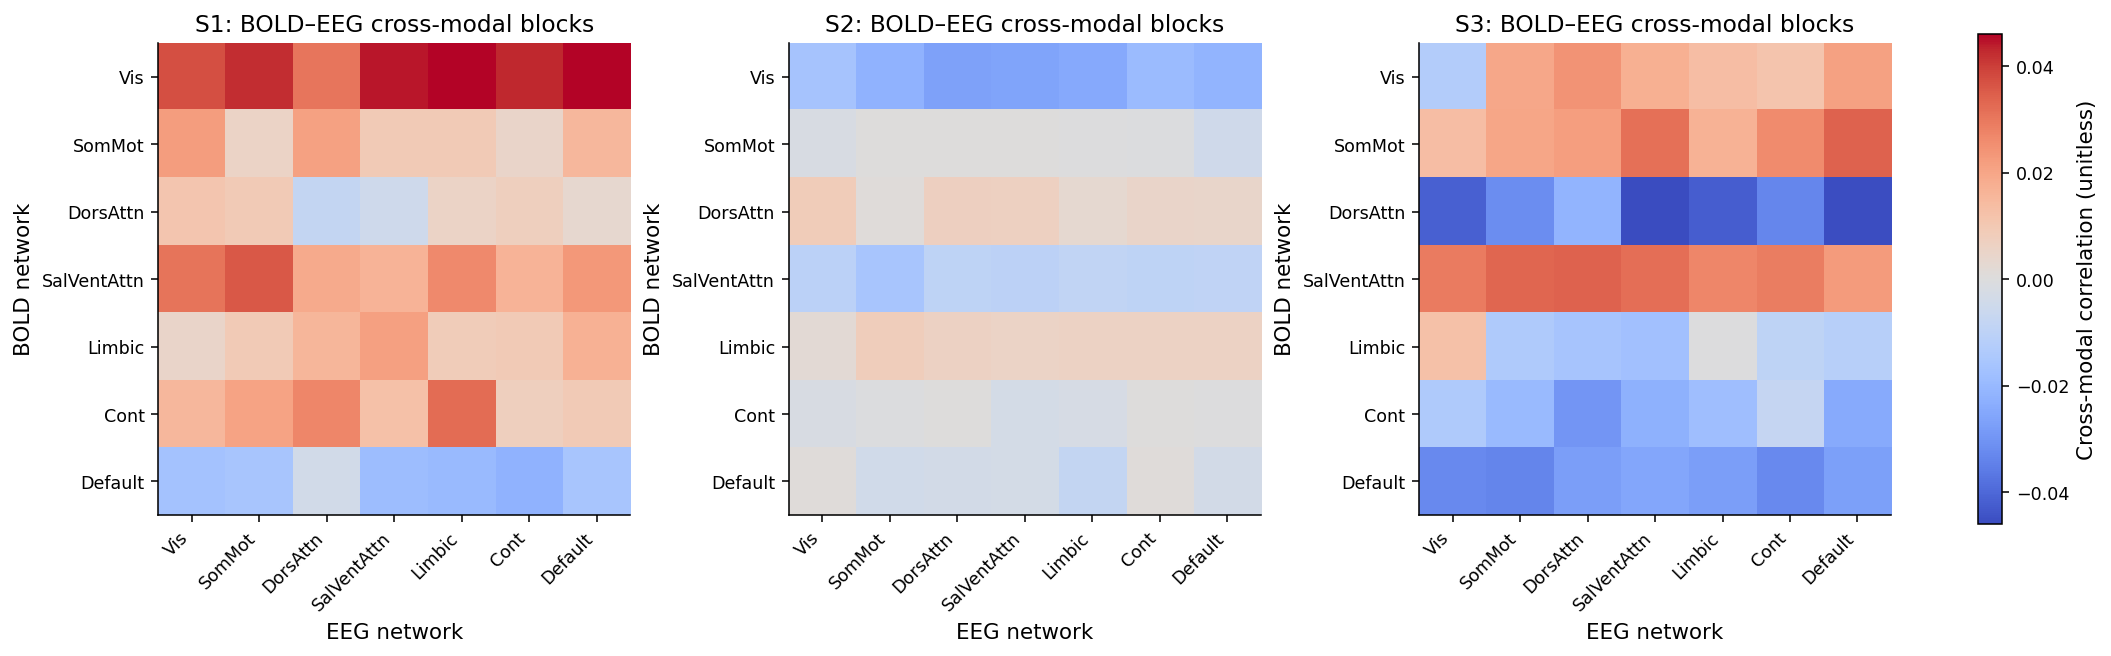

In [10]:

# Plot state-wise cross-modal block matrices

K = len(state_block_mats)
arrs = [df.values for df in state_block_mats.values()]
abs_vmax = compute_symmetric_limits(arrs, quantile=ABS_VMAX_QUANTILE)

fig, axes = plt.subplots(1, K, figsize=(5*K, 4.8), constrained_layout=True)
if K == 1:
    axes = [axes]

for ax, (state, dfb) in zip(axes, state_block_mats.items()):
    im = ax.imshow(dfb.values, cmap="coolwarm", vmin=-abs_vmax, vmax=abs_vmax)
    ax.set_title(f"{state}: BOLD–EEG cross-modal blocks")
    ax.set_xticks(range(len(dfb.columns)))
    ax.set_yticks(range(len(dfb.index)))
    ax.set_xticklabels(dfb.columns, rotation=45, ha="right")
    ax.set_yticklabels(dfb.index)
    ax.set_xlabel("EEG network")
    ax.set_ylabel("BOLD network")

cbar = fig.colorbar(im, ax=axes, shrink=0.85)
cbar.set_label("Cross-modal correlation (unitless)")
savefig(fig, "Fig_crossmodal_block_maps_states.png")


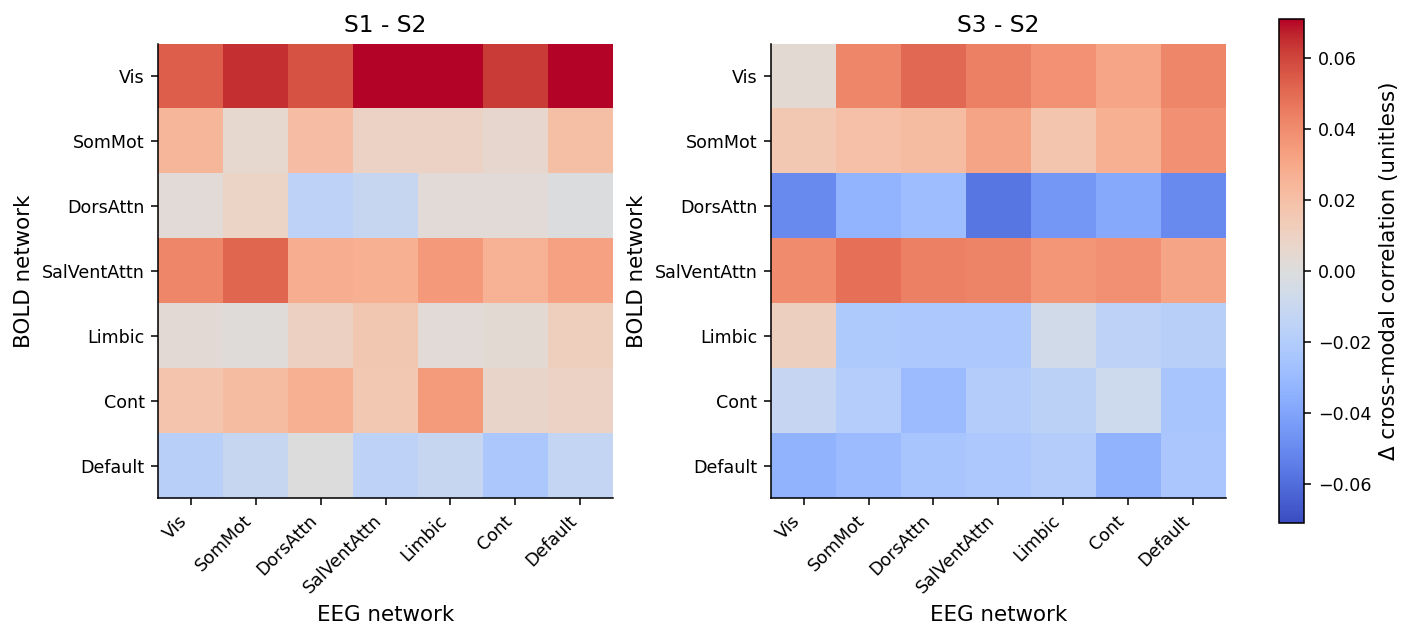

In [11]:

# Differences versus the reference state
ref_state = f"S{reference_state_idx+1}"
contrast_blocks = {}
for state, dfb in state_block_mats.items():
    if state == ref_state:
        continue
    diff = dfb - state_block_mats[ref_state]
    contrast_blocks[f"{state} - {ref_state}"] = diff
    diff.to_csv(TABLE_DIR / f"crossmodal_block_matrix_{state}_minus_{ref_state}.tsv", sep="\t")

diff_vmax = compute_symmetric_limits([d.values for d in contrast_blocks.values()], quantile=DIFF_VMAX_QUANTILE)

fig, axes = plt.subplots(1, len(contrast_blocks), figsize=(5*max(1, len(contrast_blocks)), 4.8), constrained_layout=True)
if len(contrast_blocks) == 1:
    axes = [axes]

for ax, (name, dfd) in zip(axes, contrast_blocks.items()):
    im = ax.imshow(dfd.values, cmap="coolwarm", vmin=-diff_vmax, vmax=diff_vmax)
    ax.set_title(name)
    ax.set_xticks(range(len(dfd.columns)))
    ax.set_yticks(range(len(dfd.index)))
    ax.set_xticklabels(dfd.columns, rotation=45, ha="right")
    ax.set_yticklabels(dfd.index)
    ax.set_xlabel("EEG network")
    ax.set_ylabel("BOLD network")

cbar = fig.colorbar(im, ax=axes, shrink=0.85)
cbar.set_label("Δ cross-modal correlation (unitless)")
savefig(fig, "Fig_crossmodal_block_maps_differences_vs_reference.png")


In [12]:

# Ranked cross-modal network-pair contrasts
rank_tables = []
for name, dfd in contrast_blocks.items():
    rt = rank_block_contrasts(dfd, top_n=15)
    rt.insert(0, "contrast", name)
    rank_tables.append(rt)
    rt.to_csv(TABLE_DIR / f"top_crossmodal_network_contrasts_{name.replace(' ', '_').replace('-', 'minus')}.tsv", sep="\t", index=False)

rank_all = pd.concat(rank_tables, ignore_index=True)
rank_all.to_csv(TABLE_DIR / "top_crossmodal_network_contrasts_all.tsv", sep="\t", index=False)
rank_all.head(30)


,contrast,bold_network,eeg_network,delta_value,abs_delta
0,S1 - S2,Vis,Limbic,0.076567,0.076567
1,S1 - S2,Vis,Default,0.075635,0.075635
2,S1 - S2,Vis,SalVentAttn,0.070675,0.070675
3,S1 - S2,Vis,SomMot,0.064622,0.064622
4,S1 - S2,Vis,Cont,0.062135,0.062135
5,S1 - S2,Vis,DorsAttn,0.057018,0.057018
6,S1 - S2,Vis,Vis,0.053691,0.053691
7,S1 - S2,SalVentAttn,SomMot,0.051126,0.051126
8,S1 - S2,SalVentAttn,Vis,0.041608,0.041608
9,S1 - S2,SalVentAttn,Limbic,0.035236,0.035236


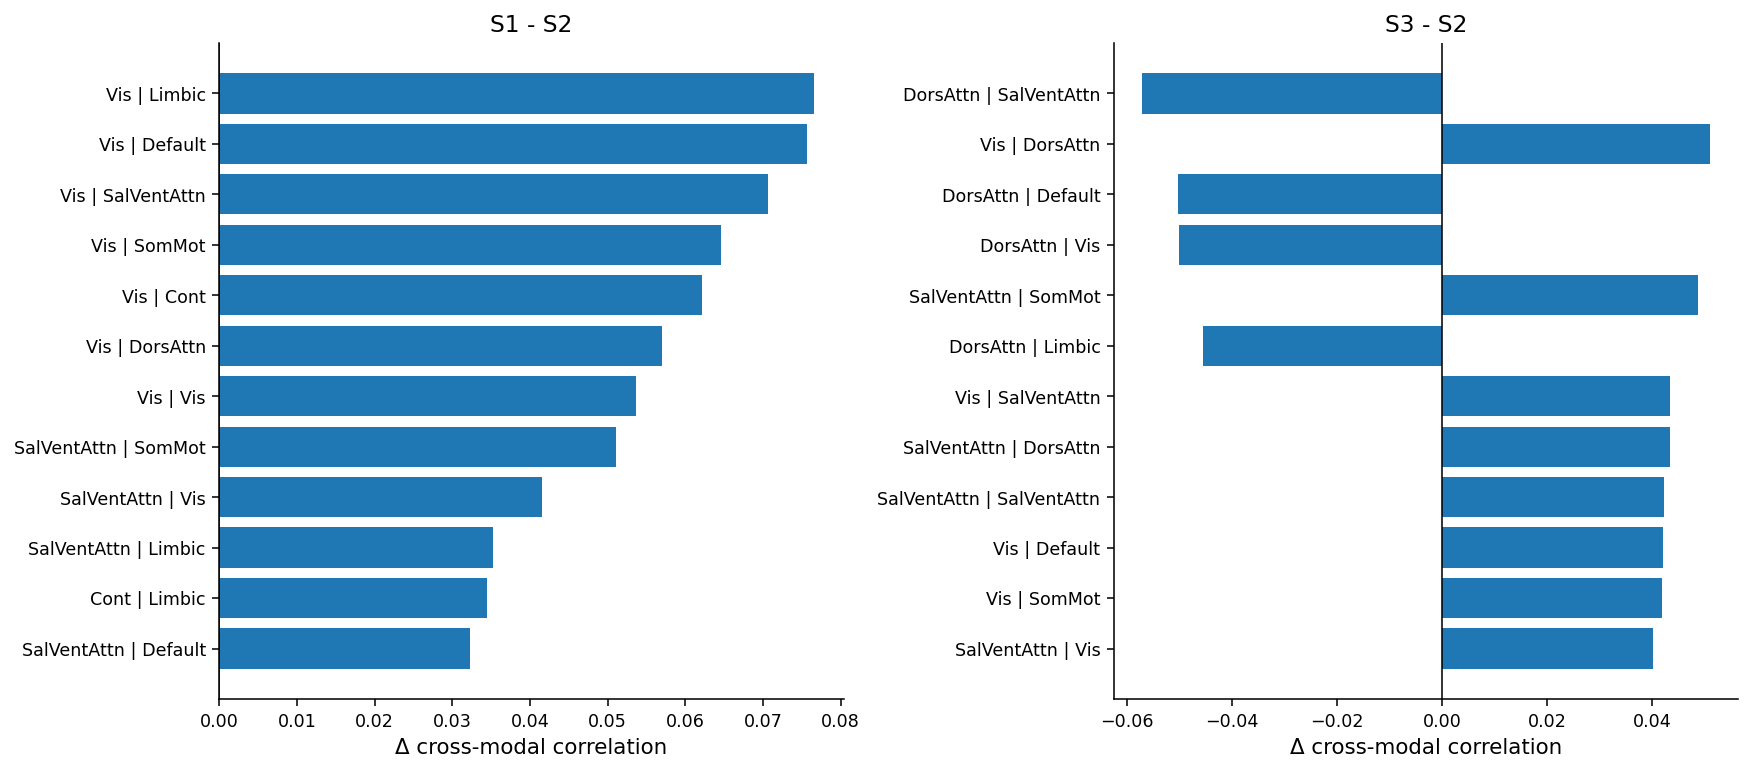

In [13]:

# Plot ranked contrasts
contrast_names = list(contrast_blocks.keys())
fig, axes = plt.subplots(1, len(contrast_names), figsize=(6.2*max(1, len(contrast_names)), 5.4), constrained_layout=True)
if len(contrast_names) == 1:
    axes = [axes]

for ax, cname in zip(axes, contrast_names):
    sub = rank_all[rank_all["contrast"] == cname].copy().head(12)
    labels_plot = [f"{r} | {c}" for r, c in zip(sub["bold_network"], sub["eeg_network"])]
    y = np.arange(len(sub))
    ax.barh(y, sub["delta_value"].values)
    ax.set_yticks(y)
    ax.set_yticklabels(labels_plot)
    ax.invert_yaxis()
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(cname)
    ax.set_xlabel("Δ cross-modal correlation")

savefig(fig, "Fig_crossmodal_ranked_network_contrasts.png")



## How to describe the cross-modal maps
For each state, the notebook backprojects the fitted PCA-space covariance into:
- a BOLD covariance block
- an EEG covariance block
- a **BOLD–EEG cross-block**

The cross-block is then normalized by the state-specific BOLD and EEG marginal standard deviations to yield a **cross-modal correlation-like matrix**:

\[
R_{BE}^{(k)}(i,j)=\frac{C_{BE}^{(k)}(i,j)}
{\sqrt{C_{BB}^{(k)}(i,i)}\,\sqrt{C_{EE}^{(k)}(j,j)}}
\]

Rows = **BOLD parcels/networks**, columns = **EEG parcels/networks**.

This is still a **descriptive summary of the fitted fusion model**, not an independent inferential test.


In [14]:

# Save a compact run manifest + session manifest
run_manifest.to_csv(TABLE_DIR / "alignment_run_manifest.tsv", sep="\t", index=False)

session_manifest = {
    "ALIGN_ROOT": str(ALIGN_ROOT),
    "RESULT_ROOT": str(RESULT_ROOT),
    "FINAL_DIR": str(FINAL_DIR),
    "chosen_run": chosen_run,
    "parcel_idx_0based": int(parcel_idx),
    "parcel_label": str(parcel_label),
    "parcel_network": str(parcel_network),
    "reference_state": f"S{reference_state_idx+1}",
    "n_states": int(crosscorr.shape[0]),
    "Vb_shape": list(Vb.shape),
    "Ve_shape": list(Ve.shape),
}
with open(TABLE_DIR / "session_manifest.json", "w", encoding="utf-8") as f:
    json.dump(session_manifest, f, indent=2)

print("Saved outputs to:")
print("  ", FIG_DIR)
print("  ", TABLE_DIR)


Saved outputs to:
   /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/fusion_methods_and_crossmodal_review/figures
   /mnt/c/EEGFMRI/hmm/R01_rerun/02_derivatives/fusion_prep/fusion_hmm_FINAL/PipelineE_final_K03_intermediate_nolags_minlen15/fusion_methods_and_crossmodal_review/tables
